# Proyecto 1 - Parte 1

## Pedro Pablo Sanín Trujillo - 202221527
## Daniel Esteban Pardo Pardo - 202311415

## Parte 1 - Importación de librerías y preprocesamiento de los textos.

Primero explicaremos el funcionamiento del procesamiento en un documento individual y luego construiremos el pipeline para aplicar las transformaciones al conjunto de datos. Inicialmente, haremos el preprocesamiento de los textos del conjunto de entrenamiento. Luego, tokenizaremos el texto para dividirlo en palabras individuales. Finalmente, hacemos stemming para que las palabras con la misma raíz sean consideradas como la misma palabra. Note que, en general, no nos interesan las terminaciones de las palabras. Por ejemplo, en el contexto del problema, las palabras: compra, compras y compramos nos transmiten básicamente la misma información. Tomar estas palabras como diferentes hace que los modelos sean innecesariamente pesados y complicados.

- Tokenización: Usaremos `word_tokenize` de `NLTK`.
- Stemming: Usaremos `SnowballStemmer` de `NLTK` con el idioma fijado en `spanish`.


In [1]:
# Importación de librerías
import nltk
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

nltk.download(
    "punkt_tab"
)  # Descargamos el tokenizador de NLTK para poder usar word_tokenize
nltk.download(
    "stopwords"
)  # Descargamos las stopwords de NLTK para poder filtrar palabras comunes

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrador\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [2]:
df = pd.read_csv("data/train.csv")

data = df.copy(deep=True)

print(f"Documentos cargados: {len(data)}")
data.head()

Documentos cargados: 12000


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [3]:
data.describe(include=["object"])

C:\Users\Administrador\AppData\Local\Temp\ipykernel_14320\2389127942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["object"])


,text,label
count,12000,12000
unique,12000,3
top,Lo pedí un martes por la noche y me llegó al d...,positivo
freq,1,4212


In [4]:
data["label"].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

Vemos que en este caso, no tenemos datos faltantes inválidos, además, el número de datos de cada categoría es mas o menos igual. Por lo que podemos proceder directamente a la tokenización y stemming.


Luego identificamos las `stop words` en español presentes en el texto. Estas son palabras que no agregan significado al texto, como y, de, un, entre otras.

Para procesar estas palabras, usamos `stopwords` de `nltk.corpus` Al final, construimos una función `tokenizer_stemmer` para aplicar la tokenización, stemming y eliminación de stopwords.

Asimismo, revisamos el conjunto de stopwords y eliminamos aquellas que expresen algo negativo, pues estas nos ayudan a clasificar correctamente los mensajes. También conservamos los conectores de contraste ("pero", "sin") y los intensificadores ("muy", "más", "mucho", "nada"), que cambian el sentido de una frase.

Muchas reseñas están escritas sin tildes ("llego", "segun", "asi"), por lo que se quitan las tildes del texto y de las stopwords antes de comparar. Así "llegó" y "llego" son el mismo token.

Por último, marcamos el alcance de la negación: a cada palabra que sigue a un negador ("no", "nunca", "sin", "nada", ...) se le agrega el prefijo `NEG_` hasta el siguiente signo de puntuación o conector adversativo. De esta forma "no me gustó la comida" produce `NEG_gust` y `NEG_com`, que el modelo distingue de `gust` y `com`.


In [5]:
import unicodedata


def quitar_tildes(text):
    """Elimina tildes y diéresis, pues muchas reseñas están escritas sin ellas."""
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")


spanish_stopwords_completas = set(stopwords.words("spanish"))

palabras_negativas = {
    "no",
    "nunca",
    "jamás",
    "nadie",
    "ninguno",
    "poco",
    "ni",
    "pero",
    "sin",
    "muy",
    "más",
    "mucho",
    "nada",
    "contra",
    "algo"
}

# Se comparan sin tildes porque el texto también se normaliza sin tildes
spanish_stopwords = {quitar_tildes(w) for w in spanish_stopwords_completas - palabras_negativas}

print(f"Cantidad de stopwords en español: {len(spanish_stopwords)}")
print(f"Contiene no: {'no' in spanish_stopwords}")
print(spanish_stopwords)

Cantidad de stopwords en español: 295
Contiene no: False
{'seriamos', 'tenga', 'tuve', 'tuvo', 'estabais', 'estoy', 'del', 'fui', 'tendra', 'fuesemos', 'una', 'para', 'habriamos', 'tuviesen', 'ha', 'fueses', 'hubieran', 'nuestra', 'tanto', 'erais', 'tendrian', 'hayan', 'hubieramos', 'fuera', 'tendriais', 'tiene', 'o', 'se', 'tuvierais', 'estuvimos', 'habriais', 'hubieses', 'tenia', 'estadas', 'hayas', 'habra', 'suyas', 'con', 'mi', 'quienes', 'serian', 'habida', 'estuviesemos', 'les', 'ellas', 'estabas', 'estaremos', 'habran', 'tienen', 'yo', 'te', 'esten', 'nuestras', 'al', 'tienes', 'tenian', 'habre', 'hubiesen', 'las', 'tuvieramos', 'fueras', 'habras', 'sentid', 'el', 'estos', 'estad', 'tengais', 'hubisteis', 'tu', 'estaban', 'tenias', 'antes', 'estan', 'tambien', 'unos', 'hubiera', 'mia', 'hubierais', 'mios', 'estuvieses', 'desde', 'nosotros', 'habian', 'le', 'por', 'ya', 'estuvieseis', 'estamos', 'habremos', 'esa', 'fuiste', 'de', 'habiais', 'nuestros', 'eres', 'seras', 'tendrias'

In [6]:
stemmer = SnowballStemmer("spanish")

# Palabras que niegan lo que viene después de ellas (sin tildes, como el texto normalizado)
NEGADORES = {"no", "nunca", "jamas", "ni", "nada", "sin", "tampoco", "nadie", "ninguno", "ninguna"}
# Tokens que cierran el alcance de una negación: puntuación y conectores adversativos
FIN_NEGACION = {".", ",", ";", ":", "!", "?", "pero", "aunque", "sino"}
NEG_PREFIX = "NEG_"


def marcar_negacion(tokens):
    """Agrega el prefijo NEG_ a las palabras dentro del alcance de una negación, es decir,
    desde el negador hasta el siguiente signo de puntuación o conector adversativo."""
    marcados, negando = [], False
    for t in tokens:
        if t in FIN_NEGACION:
            negando = False
        elif t in NEGADORES:
            negando = True
        elif negando:
            t = NEG_PREFIX + t
        marcados.append(t)
    return marcados


def tokenizer_stemmer(text, stopwords=spanish_stopwords):
    """Hacemos el preprocesamiento del texto: normalización, tokenización, marcado de negación y stemming en una sola función para luego pasarlo al pipeline de procesamiento."""
    tokens = marcar_negacion(word_tokenize(quitar_tildes(text.lower())))
    resultado = []
    for t in tokens:
        palabra = t.removeprefix(NEG_PREFIX)
        if palabra.isalpha() and palabra not in stopwords:
            prefijo = NEG_PREFIX if t.startswith(NEG_PREFIX) else ""
            resultado.append(prefijo + stemmer.stem(palabra))
    return resultado

In [7]:
ejemplo = "No me gustó para nada la batería, pero la pantalla es excelente."
tokenizer_stemmer(ejemplo)

['no', 'NEG_gust', 'nad', 'NEG_bateri', 'per', 'pantall', 'excelent']

## Parte 2 - Construcción del pipeline de preprocesamiento

A continuación, debemos construir una representación de nuestro texto que sea matemáticamente comprensible para nuestros modelos. Para hacer eso, usamos una representación en matrices dispersas. Para este propósito `sk-learn` ofrece varias formas de convertir nuestro texto en matrices dispersas.

- CountVectorizer: Produce una matriz dispersa


In [8]:
import re

TEXT_COLUMN = "text"
COLUMN_LAST_SENTENCE = "last_sentence"
COLUMN_CONTRAST = "after_contrast"
TARGET_COLUMN = "label"

VECTORIZERS = {
    "count": CountVectorizer,
    "tfidf": TfidfVectorizer,
}


def extract_last_sentences(text, n_sentences):
    """Extrae las últimas n_sentences oraciones no vacías de un texto."""
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    return ". ".join(sentences[-n_sentences:]) if sentences else ""


def add_last_sentences(X, n_sentences=1):
    """Agrega la columna con la última oración del texto, conservando las columnas originales."""
    return X.assign(
        **{COLUMN_LAST_SENTENCE: X[TEXT_COLUMN].apply(lambda x: extract_last_sentences(x, n_sentences))}
    )


# Conectores tras los cuales suele estar la opinión que define la reseña: "La pantalla es mala. Eso sí, la batería es excelente".
# "por otro lado", "en cambio" y "en general" no se incluyen porque la cláusula que sigue no predice mejor la etiqueta que la anterior.
CONECTORES_CONTRASTE = [
    "pero",
    "sin embargo",
    "aunque",
    "no obstante",
    "eso si",
    "aun asi",
    "con todo",
    "lo que si",
    "a fin de cuentas",
]
PATRON_CONTRASTE = re.compile(r"\b(?:" + "|".join(CONECTORES_CONTRASTE) + r")\b")


def extract_after_contrast(text):
    """Extrae la oración que sigue al último conector de contraste, o una cadena vacía si no hay ninguno."""
    normalizado = quitar_tildes(text.lower())
    coincidencias = list(PATRON_CONTRASTE.finditer(normalizado))
    if not coincidencias:
        return ""
    return normalizado[coincidencias[-1].end():].split(".")[0].strip(" ,")


def add_after_contrast(X):
    """Agrega la columna con la oración posterior al último conector de contraste, conservando las columnas originales."""
    return X.assign(**{COLUMN_CONTRAST: X[TEXT_COLUMN].apply(extract_after_contrast)})


def remove_first_sentence(X):
    """Elimina la primera oración del texto, conservando las columnas originales."""

    def first_sentence_removed(text):
        sentences = [s.strip() for s in text.split(".") if s.strip()]
        return ". ".join(sentences[1:]) if len(sentences) > 1 else ""

    return X.assign(**{TEXT_COLUMN: X[TEXT_COLUMN].apply(first_sentence_removed)})


def vectorizer_function(vectorizer="count"):
    return VECTORIZERS[vectorizer](
        tokenizer=tokenizer_stemmer, token_pattern=None, ngram_range=(1, 2)
    )


def char_vectorizer_function(ngram_range=(2, 5)):
    """TF-IDF de n-gramas de caracteres sobre el texto original, sin stemming ni eliminación de stopwords.
    Captura errores de ortografía, alargamientos ("buenísimooo") y morfología que el stemmer aplana."""
    return TfidfVectorizer(analyzer="char_wb", ngram_range=ngram_range, sublinear_tf=True)


def build_preprocessor(vectorizer="count", char_ngrams=False):
    """Construye el preprocesador de las features con el vectorizador indicado: 'count' o 'tfidf'.

    1. Crea la columna con la última oración y la columna con la oración posterior al último conector de contraste.
    2. Opcionalmente elimina la primera oración del texto completo (por defecto no la elimina;
       en el grid search se prueba con FunctionTransformer(remove_first_sentence)).
    3. Vectoriza por separado el texto completo, la última oración y la oración posterior al contraste.
       Con char_ngrams=True agrega además los n-gramas de caracteres del texto completo.
    """
    vectorizers = [
        ("text_vectorizer", vectorizer_function(vectorizer), TEXT_COLUMN),
        ("last_sentence_vectorizer", vectorizer_function(vectorizer), COLUMN_LAST_SENTENCE),
        ("contrast_vectorizer", vectorizer_function(vectorizer), COLUMN_CONTRAST),
    ]
    if char_ngrams:
        vectorizers.append(("char_vectorizer", char_vectorizer_function(), TEXT_COLUMN))

    return Pipeline(
        [
            ("last_sentence", FunctionTransformer(add_last_sentences, kw_args={"n_sentences": 1})),
            ("after_contrast", FunctionTransformer(add_after_contrast)),
            ("remove_first_sentence", "passthrough"),
            ("vectorizers", ColumnTransformer(vectorizers)),
        ]
    )


preprocessor = build_preprocessor("tfidf")
preprocessor

,steps,"[('last_sentence', ...), ('after_contrast', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001F28D2CC5E0>
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",{'n_sentences': 1}
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None


In [9]:
X = data.drop(TARGET_COLUMN, axis=1)
y = data[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ambos se ajustan solo con train
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


print(f"X - Train: {X_train_transformed.shape} | Test: {X_test_transformed.shape}")

X - Train: (9600, 80468) | Test: (2400, 80468)


In [10]:
vectorizers = preprocessor.named_steps["vectorizers"].named_transformers_

for name in ["text_vectorizer", "last_sentence_vectorizer", "contrast_vectorizer"]:
    print(f"Vocabulary size ({name}): {len(vectorizers[name].vocabulary_)}")

vocabulary = pd.DataFrame(
    vectorizers["text_vectorizer"].vocabulary_.items(), columns=["term", "index"]
)
vocabulary

Vocabulary size (text_vectorizer): 54132
Vocabulary size (last_sentence_vectorizer): 18387
Vocabulary size (contrast_vectorizer): 7949


,term,index
0,compr,16840
1,hac,28297
2,par,38795
3,mes,34071
4,internet,30189
...,...,...
54127,clar moment,15855
54128,compr per,17065
54129,cas darm,14651
54130,darm venc,19614


## Entrenamiento del modelo inicial de regresión logística


Accuracy Logistic Regression: 0.88875
              precision    recall  f1-score   support

    negativo       0.85      0.86      0.85       843
     neutral       0.97      0.99      0.98       715
    positivo       0.86      0.83      0.85       842

    accuracy                           0.89      2400
   macro avg       0.89      0.89      0.89      2400
weighted avg       0.89      0.89      0.89      2400



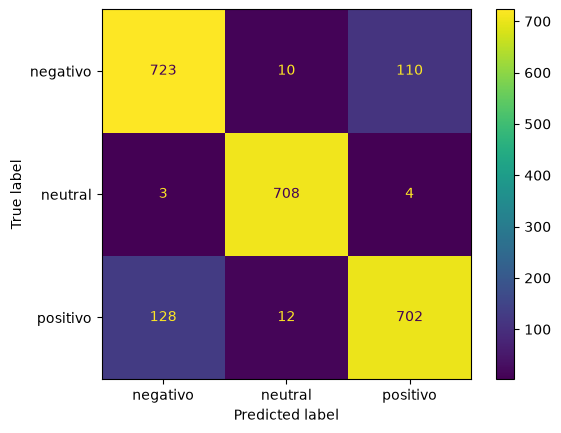

In [11]:
logistic_regression_classifier = LogisticRegression(max_iter=1000)
logistic_regression_classifier.fit(X_train_transformed, y_train)

y_pred_logistic_regression = logistic_regression_classifier.predict(X_test_transformed)

accuracy_logistic_regression = accuracy_score(y_test, y_pred_logistic_regression)
print(f"Accuracy Logistic Regression: {accuracy_logistic_regression}")
print(classification_report(y_test, y_pred_logistic_regression))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logistic_regression)
plt.show()

### Validación cruzada para hallar los mejores hiperparámetros


In [12]:
K_FOLDS = 5
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

In [13]:
param_grid_logistic_l1 = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1"],
    "classifier__solver": ["saga"],
}

param_grid_logistic_l2 = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"],
}


def with_vectorizers(param_grid, vectorizer = None):
    """Expande el grid para probar cada vectorizador ('count' o 'tfidf') en el texto completo, la última oración y la oración posterior al contraste a la vez."""
    
    if vectorizer is not None:
        return [
            {
                **param_grid,
                "remove_first_sentence": [
                    "passthrough",
                    FunctionTransformer(remove_first_sentence),
                ],
                "vectorizers__text_vectorizer": [vectorizer_function(vectorizer)],
                "vectorizers__last_sentence_vectorizer": [vectorizer_function(vectorizer)],
                "vectorizers__contrast_vectorizer": [vectorizer_function(vectorizer)],
            }
        ]
    return [
        {
            **param_grid,
            "remove_first_sentence": [
                "passthrough",
                FunctionTransformer(remove_first_sentence),
            ],
            "vectorizers__text_vectorizer": [vectorizer_function(name)],
            "vectorizers__last_sentence_vectorizer": [vectorizer_function(name)],
            "vectorizers__contrast_vectorizer": [vectorizer_function(name)],
        }
        for name in VECTORIZERS
    ]




In [14]:
pipeline_lr = Pipeline(
    [
        *build_preprocessor().steps,  # Los pasos se aplanan porque imblearn no permite Pipelines anidados
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)

grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid=with_vectorizers(param_grid_logistic_l1, vectorizer="tfidf")+with_vectorizers(param_grid_logistic_l2, vectorizer="tfidf"),
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,  # Necesario para las curvas de validación
)

grid_search_lr.fit(X_train, y_train)

c:\Users\Administrador\OneDrive - Universidad de los andes\Escritorio\ML\proyecto-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Administrador\OneDrive - Universidad de los andes\Escritorio\ML\proyecto-ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Administrador\OneDrive - Universidad de los andes\Escritorio\ML\proyecto-ml\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reach

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1'], 'classifier__solver': ['saga'], 'remove_first_sentence': ['passthrough', FunctionTrans...01F28D2CD3A0>)], ...}, {'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs'], 'remove_first_sentence': ['passthrough', FunctionTrans...01F28D2CD3A0>)], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator

Accuracy of the best Logistic Regression model: 0.8929166666666667
Best parameters of the Logistic Regression model: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'saga', 'remove_first_sentence': 'passthrough', 'vectorizers__contrast_vectorizer': TfidfVectorizer(ngram_range=(1, 2), token_pattern=None,
                tokenizer=<function tokenizer_stemmer at 0x000001F28C31FE20>), 'vectorizers__last_sentence_vectorizer': TfidfVectorizer(ngram_range=(1, 2), token_pattern=None,
                tokenizer=<function tokenizer_stemmer at 0x000001F28C31FE20>), 'vectorizers__text_vectorizer': TfidfVectorizer(ngram_range=(1, 2), token_pattern=None,
                tokenizer=<function tokenizer_stemmer at 0x000001F28C31FE20>)}
              precision    recall  f1-score   support

    negativo       0.86      0.85      0.85       843
     neutral       0.98      0.99      0.99       715
    positivo       0.85      0.85      0.85       842

    accuracy                 

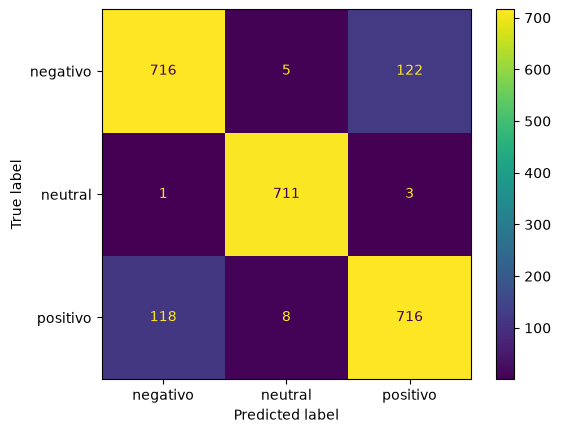

In [15]:
best_model_lr = grid_search_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy of the best Logistic Regression model: {accuracy_lr}")
print(
    f"Best parameters of the Logistic Regression model: {grid_search_lr.best_params_}"
)

print(classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_estimator(best_model_lr, X_test, y_test)
plt.show()

,first_sentence,vectorizer,penalty,C,mean_train_score,mean_test_score,std_test_score
0,Con primera oración,TfidfVectorizer,l1,100.0,1.0,0.8978,0.0074
1,Sin primera oración,TfidfVectorizer,l1,100.0,1.0,0.8907,0.0053


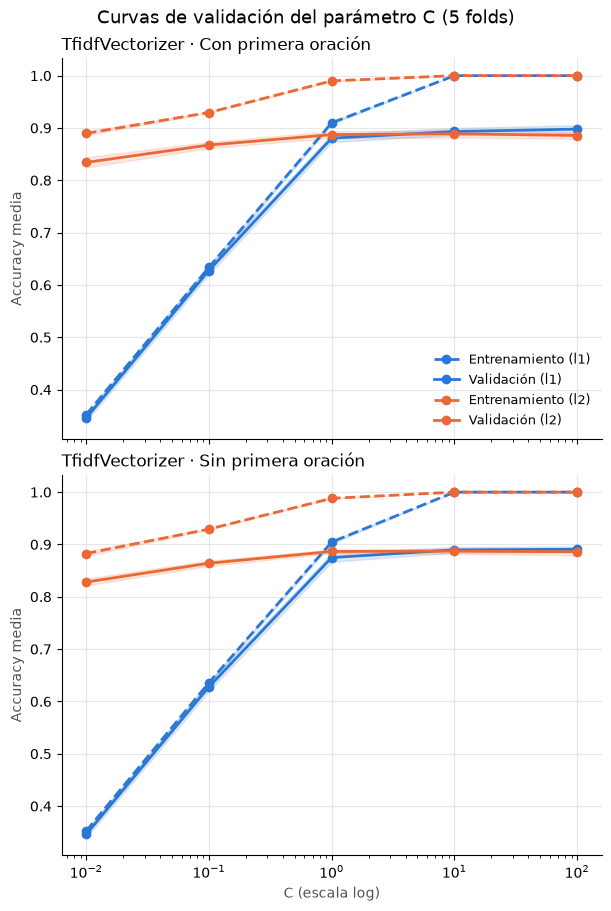

In [16]:
# Curvas de validación para C: accuracy media de entrenamiento y de validación dentro del KFold (± 1 desviación).
# Filas: se conserva o se elimina la primera oración. Columnas: vectorizador.
# Para cada penalización y valor de C se toma el solver con mejor accuracy de validación.
PENALTY_COLORS = {"l1": "#2a78d6", "l2": "#eb6834"}
SPLIT_STYLES = {"train": ("--", "Entrenamiento"), "test": ("-", "Validación")}

cv_results_lr = pd.DataFrame(grid_search_lr.cv_results_)
cv_results_lr["vectorizer"] = cv_results_lr["param_vectorizers__text_vectorizer"].map(
    lambda v: type(v).__name__
)
cv_results_lr["first_sentence"] = cv_results_lr["param_remove_first_sentence"].map(
    lambda step: (
        "Con primera oración" if step == "passthrough" else "Sin primera oración"
    )
)
cv_results_lr["penalty"] = cv_results_lr["param_classifier__penalty"]
cv_results_lr["C"] = cv_results_lr["param_classifier__C"].astype(float)

# Efecto de eliminar la primera oración: mejor configuración de cada opción
display(
    cv_results_lr.loc[
        cv_results_lr.groupby(["first_sentence", "vectorizer"])[
            "mean_test_score"
        ].idxmax(),
        [
            "first_sentence",
            "vectorizer",
            "penalty",
            "C",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
        ],
    ]
    .round(4)
    .reset_index(drop=True)
)

best_solver_idx = cv_results_lr.groupby(
    ["first_sentence", "vectorizer", "penalty", "C"]
)["mean_test_score"].idxmax()
curves = cv_results_lr.loc[best_solver_idx].sort_values("C")

first_sentence_options = curves["first_sentence"].unique()
vectorizers = curves["vectorizer"].unique()
fig, axes = plt.subplots(
    len(first_sentence_options),
    len(vectorizers),
    figsize=(6 * len(vectorizers), 4.5 * len(first_sentence_options)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)

for row, first_sentence in enumerate(first_sentence_options):
    for col, vectorizer in enumerate(vectorizers):
        ax = axes[row, col]
        subset = curves[
            (curves["first_sentence"] == first_sentence)
            & (curves["vectorizer"] == vectorizer)
        ]
        for penalty, results in subset.groupby("penalty"):
            color = PENALTY_COLORS[penalty]
            for split, (linestyle, split_label) in SPLIT_STYLES.items():
                mean = results[f"mean_{split}_score"]
                std = results[f"std_{split}_score"]
                ax.plot(
                    results["C"],
                    mean,
                    linestyle=linestyle,
                    marker="o",
                    markersize=6,
                    linewidth=2,
                    color=color,
                    label=f"{split_label} ({penalty})",
                )
                ax.fill_between(
                    results["C"], mean - std, mean + std, color=color, alpha=0.15
                )

        ax.set_xscale("log")
        ax.set_title(f"{vectorizer} · {first_sentence}", loc="left", fontsize=12)
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

for ax in axes[-1]:
    ax.set_xlabel("C (escala log)", color="#52514e")
for ax in axes[:, 0]:
    ax.set_ylabel("Accuracy media", color="#52514e")
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle(f"Curvas de validación del parámetro C ({K_FOLDS} folds)", fontsize=13)
plt.show()

In [17]:
# Bootstrapping sobre los datos de validación: se remuestrean con reemplazo las predicciones de un modelo
# para estimar la varianza de las métricas sin reentrenar.
COLOR_HIST = "#2a78d6"
COLOR_IC = "#b7d3f6"
COLOR_TEXT = "#52514e"


def bootstrap_evaluation(
    y_true,
    y_pred,
    classes=None,
    n_bootstrap=1000,
    random_state=42,
    model_name=None,
    plot=True,
):
    """Estima la distribución de accuracy y F1 (macro y por clase) remuestreando las predicciones con reemplazo.

    Sirve para cualquier clasificador: solo necesita las etiquetas reales y las predicciones sobre validación.
    Retorna el DataFrame con los resultados de cada muestra y el resumen (media, desviación, varianza e IC 95%).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.unique(y_true) if classes is None else classes
    rng = np.random.RandomState(random_state)  # resample no acepta np.random.Generator

    results = []
    for _ in range(n_bootstrap):
        y_true_sample, y_pred_sample = resample(y_true, y_pred, random_state=rng)  # type: ignore[misc]
        f1_per_class = np.asarray(
            f1_score(y_true_sample, y_pred_sample, labels=classes, average=None)
        )
        results.append(
            {
                "accuracy": accuracy_score(y_true_sample, y_pred_sample),
                "f1_macro": f1_per_class.mean(),
                **{f"f1_{label}": score for label, score in zip(classes, f1_per_class)},
            }
        )

    results = pd.DataFrame(results)

    summary = pd.DataFrame(
        {
            "media": results.mean(),
            "desviación": results.std(),
            "varianza": results.var(),
            "IC 95% inf": results.quantile(0.025),
            "IC 95% sup": results.quantile(0.975),
        }
    )
    display(summary.round(6))

    if plot:
        plot_bootstrap(results, summary, model_name=model_name)

    return results, summary


def plot_bootstrap(results, summary, model_name=None):
    """Una gráfica por métrica: distribución bootstrap, media e intervalo de confianza del 95%."""
    metrics = results.columns
    n_cols = 3
    n_rows = int(np.ceil(len(metrics) / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), constrained_layout=True
    )
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics):
        values = results[metric]
        mean = summary.loc[metric, "media"]
        lower = summary.loc[metric, "IC 95% inf"]
        upper = summary.loc[metric, "IC 95% sup"]

        ax.axvspan(lower, upper, color=COLOR_IC, alpha=0.6, label="IC 95%")
        counts, _, _ = ax.hist(
            values, bins=30, color=COLOR_HIST, edgecolor="white", linewidth=0.8
        )
        ax.set_ylim(top=counts.max() * 1.3)  # Espacio para la anotación
        ax.axvline(mean, color="#0b0b0b", linewidth=1.5, label="Media")
        for bound in (lower, upper):
            ax.axvline(bound, color=COLOR_HIST, linestyle="--", linewidth=1)

        ax.set_title(metric, loc="left", fontsize=12)
        ax.text(
            0.02,
            0.97,
            f"Media: {mean:.4f}\nIC 95%: [{lower:.4f}, {upper:.4f}]",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            color=COLOR_TEXT,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8},
        )
        ax.set_xlabel("Valor de la métrica", color=COLOR_TEXT)
        ax.set_ylabel("Frecuencia", color=COLOR_TEXT)
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    for ax in axes[len(metrics) :]:
        ax.axis("off")
    if len(axes) > len(metrics):
        axes[-1].legend(handles, labels, loc="center", frameon=False, fontsize=11)
    else:
        fig.legend(handles, labels, loc="upper right", frameon=False)
    title = f"Distribución bootstrap de las métricas ({len(results)} muestras)"
    fig.suptitle(f"{title} · {model_name}" if model_name else title, fontsize=14)
    plt.show()

,media,desviación,varianza,IC 95% inf,IC 95% sup
accuracy,0.893076,0.006350,0.000040,0.880833,0.905417
f1_macro,0.897585,0.005979,0.000036,0.886108,0.908790
f1_negativo,0.853557,0.009427,0.000089,0.836110,0.871359
f1_neutral,0.988325,0.002867,0.000008,0.982456,0.993353
f1_positivo,0.850873,0.009471,0.000090,0.831946,0.868224


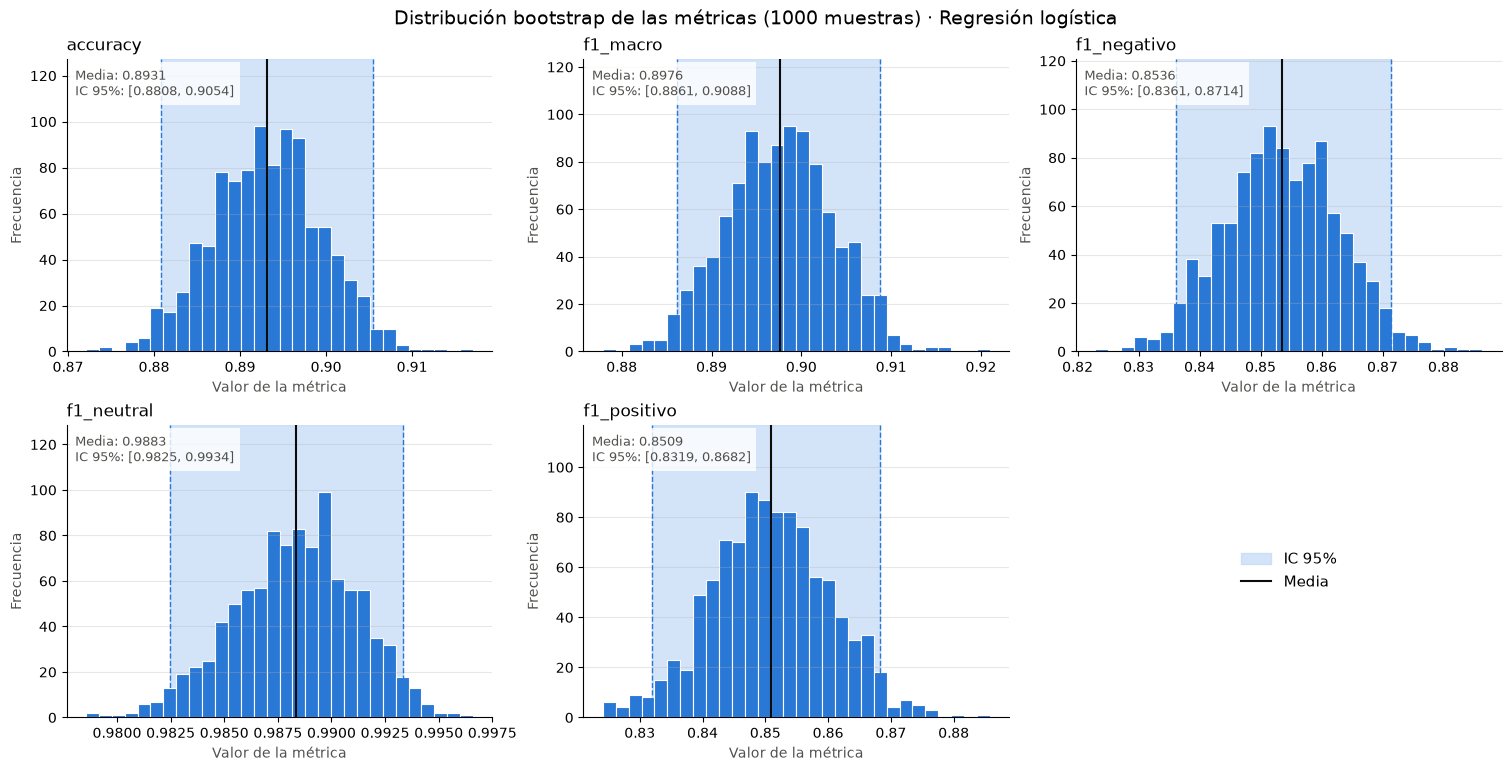

In [18]:
bootstrap_results_lr, bootstrap_summary_lr = bootstrap_evaluation(
    y_test, y_pred_lr, classes=best_model_lr.classes_, model_name="Regresión logística"
)

## Árbol de decision


Accuracy Decision Tree: 0.59625
              precision    recall  f1-score   support

    negativo       0.48      0.72      0.58       843
     neutral       0.87      0.75      0.81       715
    positivo       0.54      0.34      0.41       842

    accuracy                           0.60      2400
   macro avg       0.63      0.60      0.60      2400
weighted avg       0.62      0.60      0.59      2400



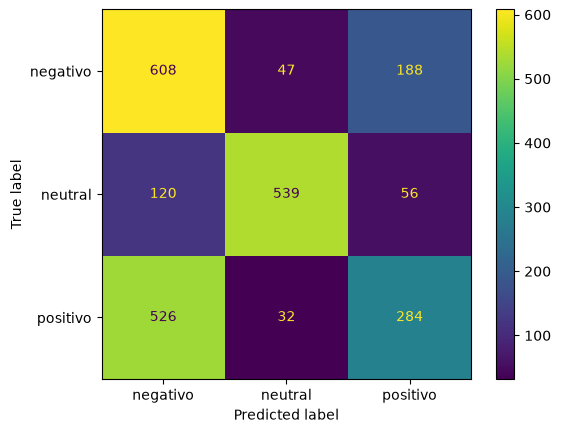

In [19]:
# Entrenamiento y evaluación del modelo Decision Tree con profundidad máxima de 10
decision_tree_classifier = DecisionTreeClassifier(max_depth=10)
decision_tree_classifier.fit(X_train_transformed, y_train)
y_pred_dt = decision_tree_classifier.predict(X_test_transformed)

accuracy_decision_tree = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy Decision Tree: {accuracy_decision_tree}")
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.show()

In [20]:
# Con texto vectorizado (disperso y de alta dimensión) el árbol necesita más profundidad,
# así que se amplía max_depth y se controla el sobreajuste con poda por complejidad (ccp_alpha).
# Se descartan splitter="random" y max_features="log2", que con miles de features apenas usan información.
param_grid_dt = {
    "max_depth": [80,100,120,140, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt"],
    "ccp_alpha": [0.0, 1e-4, 5e-4, 1e-3],
}
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid_dt,
    scoring="accuracy",
    cv=kfold,
    n_jobs=-1,
    return_train_score=True,
)

grid_search_dt.fit(X_train_transformed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.0, 0.0001, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [80, 100, ...], 'max_features': [None, 'sqrt'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` 

Accuracy Decision Tree (Grid Search): 0.725
              precision    recall  f1-score   support

    negativo       0.66      0.69      0.68       843
     neutral       0.83      0.86      0.85       715
    positivo       0.69      0.64      0.67       842

    accuracy                           0.72      2400
   macro avg       0.73      0.73      0.73      2400
weighted avg       0.72      0.72      0.72      2400



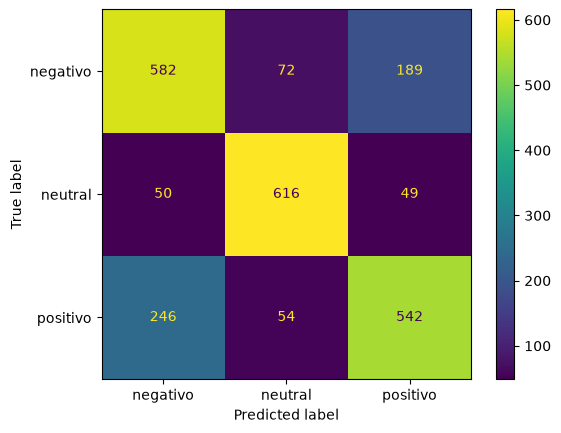

In [21]:
# Entrenamiento y evaluación del modelo Decision Tree con búsqueda en cuadrícula (Grid Search)
best_model_dt = grid_search_dt.best_estimator_
y_pred_grid_dt = best_model_dt.predict(X_test_transformed)

accuracy_grid_decision_tree = accuracy_score(y_test, y_pred_grid_dt)
print(f"Accuracy Decision Tree (Grid Search): {accuracy_grid_decision_tree}")
print(classification_report(y_test, y_pred_grid_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_grid_dt)
plt.show()

,media,desviación,varianza,IC 95% inf,IC 95% sup
accuracy,0.724776,0.009102,0.000083,0.707490,0.743333
f1_macro,0.729768,0.008806,0.000078,0.712685,0.748043
f1_negativo,0.675568,0.013308,0.000177,0.650048,0.702216
f1_neutral,0.846002,0.010322,0.000107,0.825648,0.865955
f1_positivo,0.667733,0.013158,0.000173,0.642813,0.693335


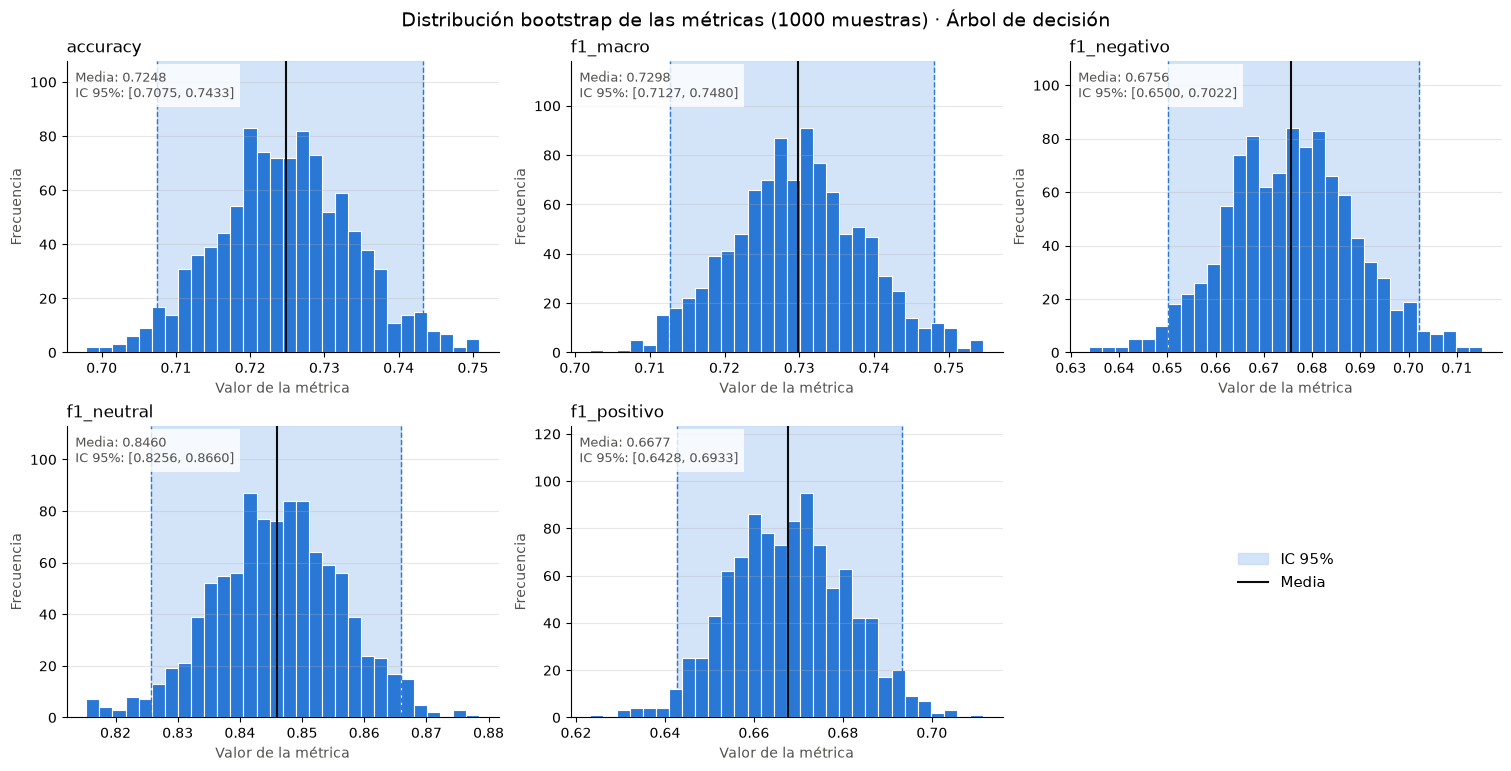

In [22]:
# Bootstrap evaluation of the best Decision Tree model
bootstrap_results_dt, bootstrap_summary_dt = bootstrap_evaluation(
    y_test,
    y_pred_grid_dt,
    classes=best_model_dt.classes_,
    model_name="Árbol de decisión",
)

## AdaBoost


Accuracy AdaBoost: 0.805
              precision    recall  f1-score   support

    negativo       0.73      0.74      0.73       843
     neutral       0.98      0.99      0.98       715
    positivo       0.73      0.71      0.72       842

    accuracy                           0.81      2400
   macro avg       0.81      0.81      0.81      2400
weighted avg       0.80      0.81      0.80      2400



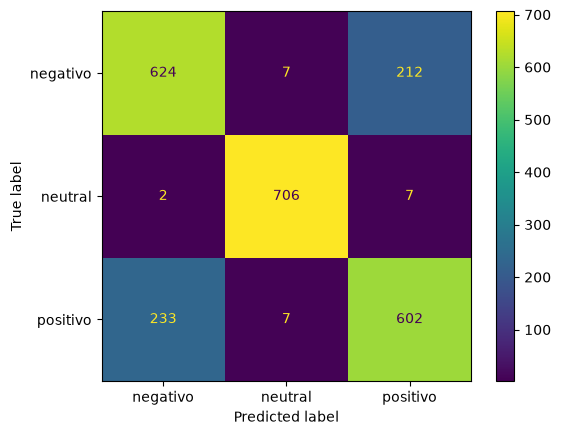

In [23]:
ada_classifier = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=1000, learning_rate=1.0)
ada_classifier.fit(X_train_transformed, y_train)
y_pred_ab = ada_classifier.predict(X_test_transformed)

accuracy_adaboost = accuracy_score(y_test, y_pred_ab)
print(f"Accuracy AdaBoost: {accuracy_adaboost}")
print(classification_report(y_test, y_pred_ab))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ab)
plt.show()

In [ ]:
# Grid search de AdaBoost dentro del mismo pipeline que la regresión logística, para que también
# se prueben el vectorizador TF-IDF y la eliminación de la primera oración.
# Se usan árboles poco profundos como weak learners: con árboles profundos el boosting casi no corrige errores.
param_grid_ab = {
    "classifier__estimator__max_depth": [1, 2, 3],
    "classifier__n_estimators": [300, 600],
    "classifier__learning_rate": [0.1, 0.5, 1.0],
}

pipeline_ab = Pipeline(
    [
        *build_preprocessor().steps,  # Los pasos se aplanan porque imblearn no permite Pipelines anidados
        (
            "classifier",
            AdaBoostClassifier(
                estimator=DecisionTreeClassifier(random_state=42), random_state=42
            ),
        ),
    ]
)

grid_search_ab = GridSearchCV(
    pipeline_ab,
    param_grid=with_vectorizers(param_grid_ab, vectorizer="tfidf"),
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,  # Necesario para las curvas de validación
)

grid_search_ab.fit(X_train, y_train)

In [ ]:
best_model_adaboost = grid_search_ab.best_estimator_

y_pred_best_adaboost = best_model_adaboost.predict(X_test)

accuracy_best_adaboost = accuracy_score(y_test, y_pred_best_adaboost)
print(f"Accuracy AdaBoost Classifier: {accuracy_best_adaboost}")
print(classification_report(y_test, y_pred_best_adaboost))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_adaboost)
plt.show()

## Random Forest

Accuracy Random Forest: 0.7675
              precision    recall  f1-score   support

    negativo       0.72      0.67      0.70       843
     neutral       0.87      0.99      0.92       715
    positivo       0.71      0.67      0.69       842

    accuracy                           0.77      2400
   macro avg       0.77      0.78      0.77      2400
weighted avg       0.76      0.77      0.76      2400



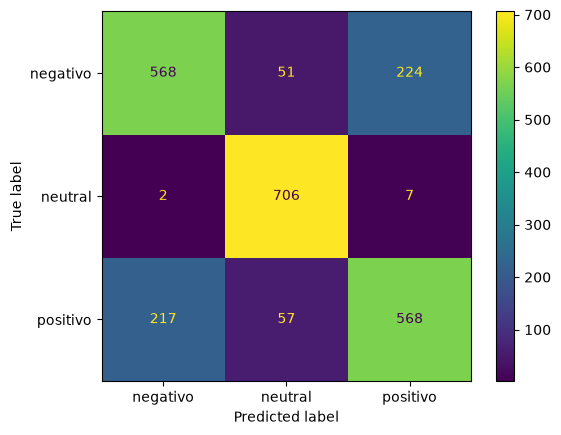

In [25]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train_transformed, y_train)
y_pred = random_forest.predict(X_test_transformed)
accuracy_random_forest = accuracy_score(y_test, y_pred)
print(f"Accuracy Random Forest: {accuracy_random_forest}")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
# Grid search de Random Forest dentro del mismo pipeline que la regresión logística, para que también
# se prueben el vectorizador TF-IDF y la eliminación de la primera oración.
param_grid_rf = {
    "classifier__n_estimators": [300, 600],
    "classifier__max_depth": [None, 20, 50],
    "classifier__max_features": ["sqrt", "log2", 0.1],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"],
}

pipeline_rf = Pipeline(
    [
        *build_preprocessor().steps,  # Los pasos se aplanan porque imblearn no permite Pipelines anidados
        ("classifier", RandomForestClassifier(random_state=42, n_jobs=1)),
    ]
)

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid=with_vectorizers(param_grid_rf, vectorizer="tfidf"),
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,  # Necesario para las curvas de validación
)

grid_search_rf.fit(X_train, y_train)

# SVC

Accuracy Support Vector Classifier: 0.8991666666666667
              precision    recall  f1-score   support

    negativo       0.85      0.88      0.86       843
     neutral       0.98      0.99      0.99       715
    positivo       0.88      0.84      0.86       842

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



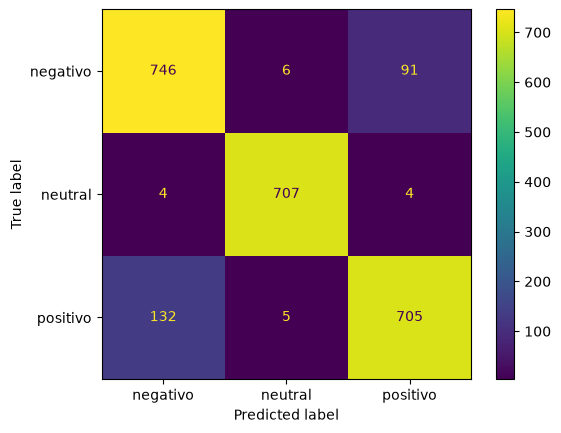

In [26]:
support_vector_classifier = SVC(kernel='sigmoid', C=1.0)

support_vector_classifier.fit(X_train_transformed, y_train)
y_pred_svc = support_vector_classifier.predict(X_test_transformed)

accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy Support Vector Classifier: {accuracy_svc}")
print(classification_report(y_test, y_pred_svc))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc)
plt.show()

In [ ]:
# Grid search de SVC dentro del mismo pipeline que la regresión logística, para que también
# se prueben el vectorizador TF-IDF y la eliminación de la primera oración.
# Con texto disperso y de alta dimensión el kernel lineal suele bastar; se compara con rbf y sigmoid.
param_grid_svc_linear = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear"],
}

param_grid_svc_rbf = {
    "classifier__C": [1, 10, 100],
    "classifier__kernel": ["rbf", "sigmoid"],
    "classifier__gamma": ["scale", 0.1, 1],
}

pipeline_svc = Pipeline(
    [
        *build_preprocessor().steps,  # Los pasos se aplanan porque imblearn no permite Pipelines anidados
        ("classifier", SVC(random_state=42)),
    ]
)

grid_search_svc = GridSearchCV(
    pipeline_svc,
    param_grid=with_vectorizers(param_grid_svc_linear, vectorizer="tfidf")
    + with_vectorizers(param_grid_svc_rbf, vectorizer="tfidf"),
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,  # Necesario para las curvas de validación
)

grid_search_svc.fit(X_train, y_train)

In [ ]:
best_model_svc = grid_search_svc.best_estimator_

y_pred_best_svc = best_model_svc.predict(X_test)

accuracy_best_svc = accuracy_score(y_test, y_pred_best_svc)
print(f"Accuracy Support Vector Classifier: {accuracy_best_svc}")
print(f"Best parameters of the SVC model: {grid_search_svc.best_params_}")
print(classification_report(y_test, y_pred_best_svc))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_svc)
plt.show()

In [ ]:
# Bootstrap evaluation of the best Decision Tree model
bootstrap_results_dt, bootstrap_summary_dt = bootstrap_evaluation(
    y_test,
    y_pred_best_svc,
    classes=best_model_svc.classes_,
    model_name="Support Vector Classifier",
)

### Linear SVC

Accuracy Linear Support Vector Classifier: 0.89375
              precision    recall  f1-score   support

    negativo       0.86      0.85      0.85       843
     neutral       0.98      0.99      0.99       715
    positivo       0.86      0.85      0.85       842

    accuracy                           0.89      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.89      0.89      0.89      2400



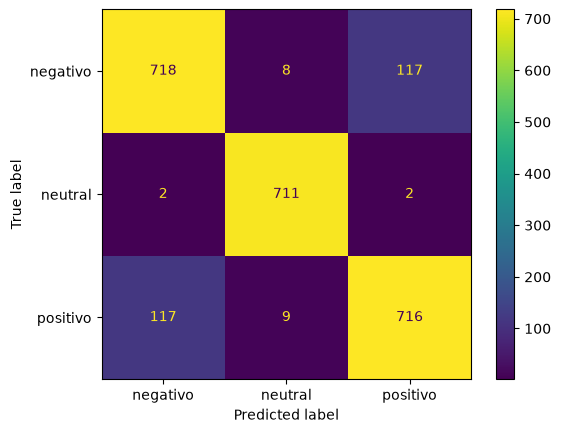

In [27]:
linear_svc = LinearSVC(C=1.0)
linear_svc.fit(X_train_transformed, y_train)
y_pred_linear_svc = linear_svc.predict(X_test_transformed)
accuracy_linear_svc = accuracy_score(y_test, y_pred_linear_svc)
print(f"Accuracy Linear Support Vector Classifier: {accuracy_linear_svc}")
print(classification_report(y_test, y_pred_linear_svc))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_linear_svc)
plt.show()


In [28]:
# Comparación en validación cruzada (solo train) del preprocesador con y sin n-gramas de caracteres
for char_ngrams in [False, True]:
    for name, classifier in [
        ("LinearSVC", LinearSVC(C=1.0)),
        ("LogisticRegression", LogisticRegression(C=10, max_iter=3000)),
    ]:
        pipeline_char = Pipeline(
            [*build_preprocessor("tfidf", char_ngrams=char_ngrams).steps, ("classifier", classifier)]
        )
        scores = cross_val_score(pipeline_char, X_train, y_train, cv=kfold, n_jobs=-1)
        print(f"char_ngrams={char_ngrams!s:5} {name:18} {scores.mean():.4f} ± {scores.std():.4f}")

char_ngrams=False LinearSVC          0.8907 ± 0.0047
char_ngrams=False LogisticRegression 0.8890 ± 0.0073
char_ngrams=True  LinearSVC          0.8909 ± 0.0071
char_ngrams=True  LogisticRegression 0.8902 ± 0.0082


,media,desviación,varianza,IC 95% inf,IC 95% sup
accuracy,0.893850,0.006288,0.000040,0.881667,0.906667
f1_macro,0.898083,0.005921,0.000035,0.886515,0.909850
f1_negativo,0.854907,0.009183,0.000084,0.837930,0.873165
f1_neutral,0.985585,0.003272,0.000011,0.978693,0.991342
f1_positivo,0.853758,0.009330,0.000087,0.836011,0.872154


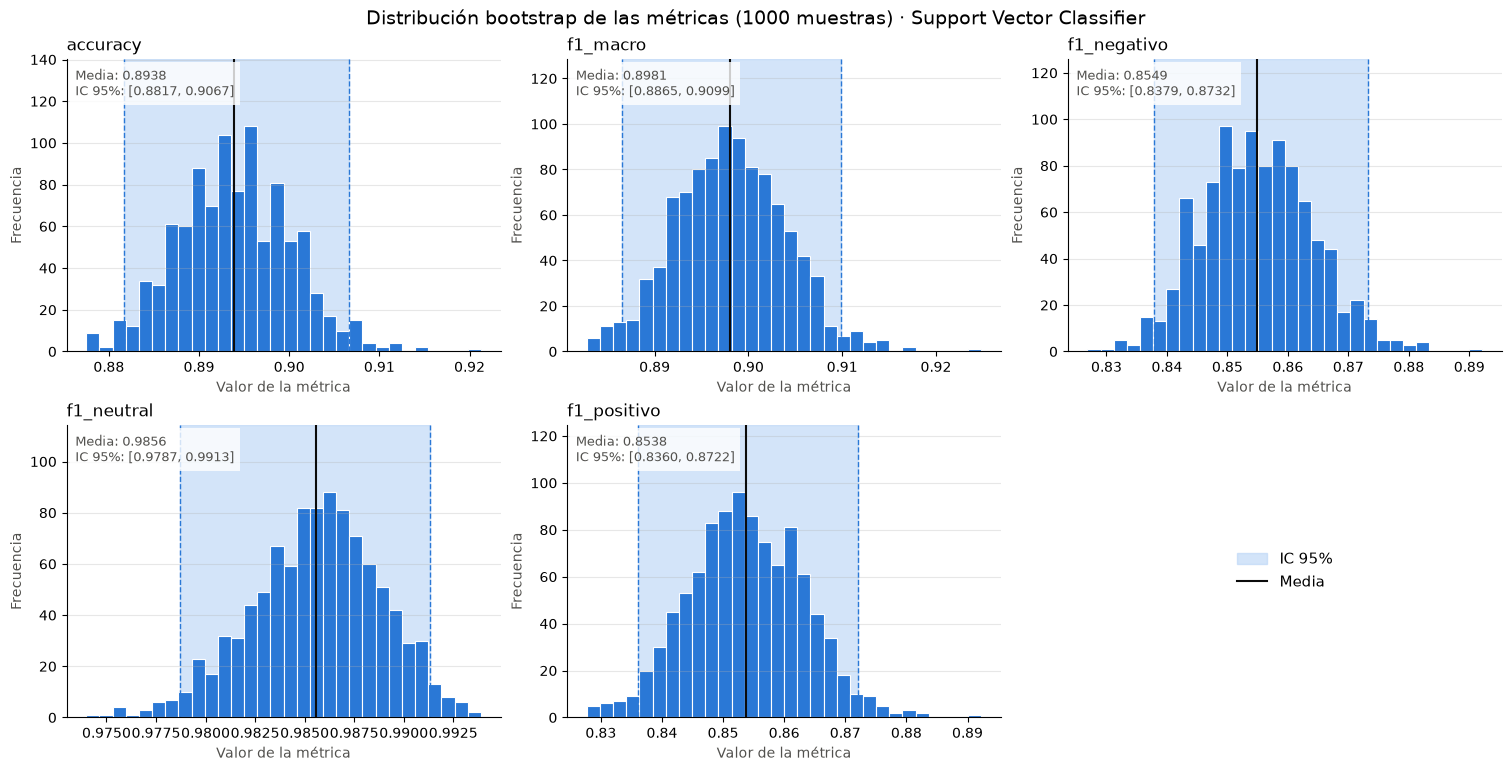

In [29]:
bootstrap_results_svc, bootstrap_summary_svc = bootstrap_evaluation(
    y_test,
    y_pred_linear_svc,
    classes=linear_svc.classes_,
    model_name="Support Vector Classifier",
)

## Viendo como clasificar positivo y negativo.
Primero, encontraremos algunas muestras mal clasificadas en el mejor modelo hasta ahora (SVC) y veremos su estructura.

En las entradas mal clasificadas, identifiqué que en general, el origen de la mala clasificación está en que las reseñas son ambiguas o cambian de significado. Creemos un modelo que solamente distinga entre positivo y negativo.

In [30]:
X_train_no_neutros = X_train[y_train != "neutral"]
y_train_no_neutros = y_train[y_train != "neutral"]

X_test_no_neutros = X_test[y_test != "neutral"]
y_test_no_neutros = y_test[y_test != "neutral"]

# Se ajusta solo con train y se reutiliza en test para mantener el mismo vocabulario
preprocessor_no_neutros = build_preprocessor("tfidf")
X_train_no_neutros_transformed = preprocessor_no_neutros.fit_transform(X_train_no_neutros)
X_test_no_neutros_transformed = preprocessor_no_neutros.transform(X_test_no_neutros)




Accuracy without neutral class: 0.8694362017804155
              precision    recall  f1-score   support

    negativo       0.86      0.88      0.87       843
    positivo       0.88      0.85      0.87       842

    accuracy                           0.87      1685
   macro avg       0.87      0.87      0.87      1685
weighted avg       0.87      0.87      0.87      1685



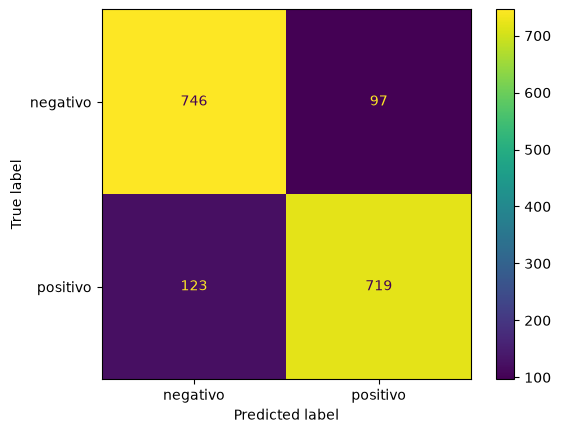

In [31]:
svc_no_neutros = SVC(kernel='sigmoid', C=1.0, gamma=1)
svc_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros = svc_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros = accuracy_score(y_test_no_neutros, y_pred_no_neutros)
print("Accuracy without neutral class:", accuracy_no_neutros)

print(classification_report(y_test_no_neutros, y_pred_no_neutros))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros)
plt.show()


Accuracy without neutral class (Decision Tree): 0.7922848664688428
              precision    recall  f1-score   support

    negativo       0.78      0.82      0.80       843
    positivo       0.81      0.76      0.79       842

    accuracy                           0.79      1685
   macro avg       0.79      0.79      0.79      1685
weighted avg       0.79      0.79      0.79      1685



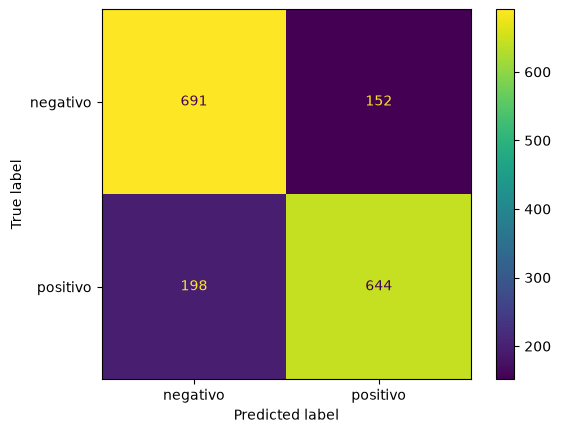

In [32]:
decision_tree_no_neutros = DecisionTreeClassifier()
decision_tree_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros_dt = decision_tree_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros_dt = accuracy_score(y_test_no_neutros, y_pred_no_neutros_dt)
print("Accuracy without neutral class (Decision Tree):", accuracy_no_neutros_dt)

print(classification_report(y_test_no_neutros, y_pred_no_neutros_dt))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros_dt)
plt.show()

Accuracy without neutral class (AdaBoost): 0.8083086053412463
              precision    recall  f1-score   support

    negativo       0.88      0.71      0.79       843
    positivo       0.76      0.91      0.83       842

    accuracy                           0.81      1685
   macro avg       0.82      0.81      0.81      1685
weighted avg       0.82      0.81      0.81      1685



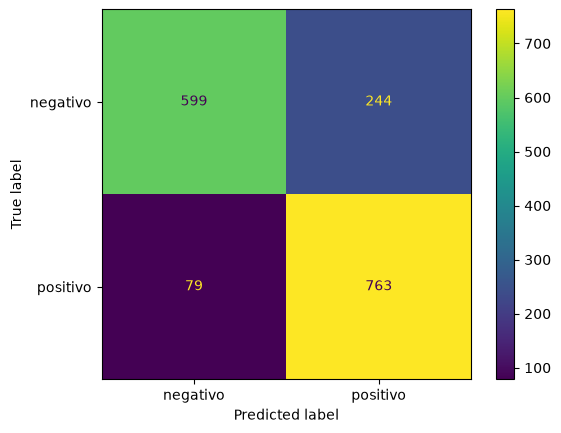

In [33]:
decision_tree_no_neutros = AdaBoostClassifier(n_estimators=1000, learning_rate=1)
decision_tree_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros_dt = decision_tree_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros_dt = accuracy_score(y_test_no_neutros, y_pred_no_neutros_dt)
print("Accuracy without neutral class (AdaBoost):", accuracy_no_neutros_dt)

print(classification_report(y_test_no_neutros, y_pred_no_neutros_dt))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros_dt)
plt.show()

Accuracy without neutral class (Random Forest): 0.8338278931750742
              precision    recall  f1-score   support

    negativo       0.84      0.83      0.83       843
    positivo       0.83      0.84      0.83       842

    accuracy                           0.83      1685
   macro avg       0.83      0.83      0.83      1685
weighted avg       0.83      0.83      0.83      1685



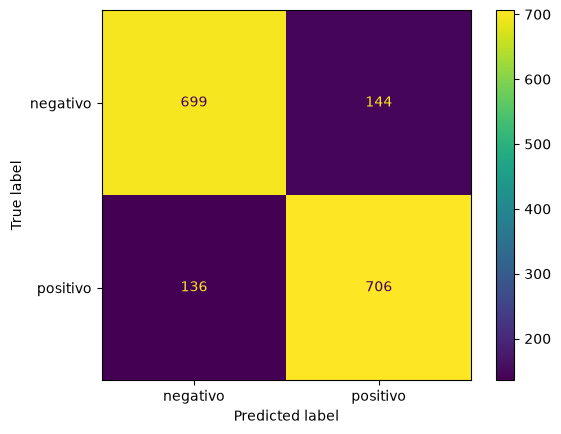

In [34]:
random_forest_no_neutros = RandomForestClassifier(n_estimators=1000, max_depth=3, random_state=42)
random_forest_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros_rf = random_forest_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros_rf = accuracy_score(y_test_no_neutros, y_pred_no_neutros_rf)
print("Accuracy without neutral class (Random Forest):", accuracy_no_neutros_rf)

print(classification_report(y_test_no_neutros, y_pred_no_neutros_rf))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros_rf)
plt.show()

Accuracy without neutral class (KNN): 0.7887240356083086
              precision    recall  f1-score   support

    negativo       0.79      0.79      0.79       843
    positivo       0.79      0.79      0.79       842

    accuracy                           0.79      1685
   macro avg       0.79      0.79      0.79      1685
weighted avg       0.79      0.79      0.79      1685



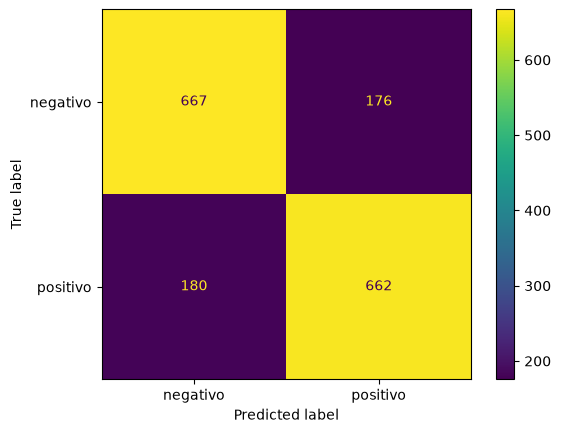

In [35]:
knn_no_neutros = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_no_neutros.fit(X_train_no_neutros_transformed, y_train_no_neutros)
y_pred_no_neutros_knn = knn_no_neutros.predict(X_test_no_neutros_transformed)
accuracy_no_neutros_knn = accuracy_score(y_test_no_neutros, y_pred_no_neutros_knn)
print("Accuracy without neutral class (KNN):", accuracy_no_neutros_knn)

print(classification_report(y_test_no_neutros, y_pred_no_neutros_knn))
ConfusionMatrixDisplay.from_predictions(y_test_no_neutros, y_pred_no_neutros_knn)
plt.show()

## Clasificación en cascada (dos etapas)

Los resultados de los modelos anteriores muestran un patrón muy claro: la clase **neutral casi nunca se confunde** (F1 ≈ 0.985 con `LinearSVC`), mientras que **positivo y negativo se quedan en F1 ≈ 0.85**. Es decir, prácticamente todo el error del modelo está en separar una reseña positiva de una negativa.

Los clasificadores planos construidos hasta ahora usan un único modelo para dos problemas de naturaleza distinta. La idea de la **clasificación en cascada** es separarlos:

1. **Etapa 1 – detector de neutral:** clasificador binario *neutral* vs. *no neutral*, entrenado con todas las reseñas.
2. **Etapa 2 – clasificador de opuestos:** clasificador binario *positivo* vs. *negativo*, entrenado **solo con las reseñas que no son neutrales**. Así este modelo se especializa en la parte difícil y no tiene que "repartir capacidad" con la clase neutral.

La predicción final es: si la etapa 1 dice *neutral*, la reseña es neutral; si no, la etiqueta la decide la etapa 2.

En la sección anterior ya entrenamos modelos solo con positivos y negativos (`*_no_neutros`), pero evaluados de forma aislada sobre reseñas que ya sabíamos que no eran neutrales. Aquí los **conectamos con un detector de neutral** para obtener una predicción final de tres clases y poder compararla, en igualdad de condiciones, con el modelo plano.

### Diseño

- Se reutiliza el preprocesador `build_preprocessor("tfidf")` (texto completo, última oración y oración posterior al contraste), el mismo `kfold` y la función `bootstrap_evaluation` ya definidos.
- Se implementan dos funciones, `entrenar_cascada` y `predecir_cascada`, que reciben cualquier modelo de scikit-learn. La primera entrena las dos etapas (la etapa 2 solo con las reseñas que no son neutrales) y la segunda combina sus predicciones.
- **Para evitar fuga de información**, en la validación cruzada el preprocesador (vocabulario e IDF) se ajusta *dentro de cada fold*, solo con los datos de entrenamiento de ese fold.

In [37]:
def entrenar_cascada(X, y, modelo_neutral, modelo_polaridad):
    y = np.asarray(y)
    es_neutral = y == "neutral"
    modelo_neutral.fit(X, es_neutral)                       # etapa 1: todas las reseñas
    modelo_polaridad.fit(X[~es_neutral], y[~es_neutral])    # etapa 2: solo positivas y negativas
    return modelo_neutral, modelo_polaridad


def predecir_cascada(X, modelo_neutral, modelo_polaridad):
    return np.where(modelo_neutral.predict(X), "neutral", modelo_polaridad.predict(X))

### Validación cruzada: cascada vs. modelo plano

Comparamos, con los mismos 5 folds (`kfold`), el `LinearSVC` plano de tres clases (el mejor modelo hasta ahora) contra varias cascadas. En todas, la etapa 1 es un `LinearSVC` (C=1). Lo que variamos es el clasificador de la **etapa 2**, que es donde está el error: `LinearSVC` con distintos valores de `C`, regresión logística y `RidgeClassifier`.

Además de la accuracy final, medimos el desempeño de cada etapa por separado:
- **Etapa 1:** accuracy del detector *neutral vs. no neutral* sobre el fold de validación.
- **Etapa 2:** accuracy *positivo vs. negativo* solo sobre las reseñas que realmente son positivas o negativas, es decir, el desempeño del especialista si la etapa 1 no se equivocara.

In [46]:

configuraciones = {
    "Cascada: SVC / SVC (C2=0.3)": lambda: (LinearSVC(C=1.0), LinearSVC(C=0.3)),
    "Cascada: SVC / SVC (C2=1)": lambda: (LinearSVC(C=1.0), LinearSVC(C=1.0)),
    "Cascada: SVC / SVC (C2=3)": lambda: (LinearSVC(C=1.0), LinearSVC(C=3.0)),
    "Cascada: SVC / Reg. logística": lambda: (LinearSVC(C=1.0), LogisticRegression(C=10, max_iter=3000)),
}
scores_cv = {"Plano: LinearSVC (C=1)": []} | {nombre: [] for nombre in configuraciones}
f1_etapa1, f1_etapa2 = [], []

for train_idx, val_idx in kfold.split(X_train):
    prep_fold = build_preprocessor("tfidf")                       # se ajusta solo con el fold de entrenamiento
    X_tr = prep_fold.fit_transform(X_train.iloc[train_idx])
    X_val = prep_fold.transform(X_train.iloc[val_idx])
    y_tr = y_train.iloc[train_idx].values
    y_val = y_train.iloc[val_idx].values

    plano = LinearSVC(C=1.0).fit(X_tr, y_tr)
    scores_cv["Plano: LinearSVC (C=1)"].append(f1_score(y_val, plano.predict(X_val), average="macro"))

    for nombre, crear in configuraciones.items():
        etapa1, etapa2 = entrenar_cascada(X_tr, y_tr, *crear())
        scores_cv[nombre].append(f1_score(y_val, predecir_cascada(X_val, etapa1, etapa2), average="macro"))

    # Diagnóstico por etapa (cascada base C2=1)
    etapa1, etapa2 = entrenar_cascada(X_tr, y_tr, LinearSVC(C=1.0), LinearSVC(C=1.0))
    f1_etapa1.append(f1_score(y_val == "neutral", etapa1.predict(X_val)))
    no_neutral = y_val != "neutral"
    f1_etapa2.append(f1_score(y_val[no_neutral], etapa2.predict(X_val[no_neutral]), average="macro"))

resultados_cv = pd.DataFrame({
    "f1_macro media": {n: np.mean(s) for n, s in scores_cv.items()},
    "desviación": {n: np.std(s) for n, s in scores_cv.items()},
}).round(4)
display(resultados_cv)
print(f"Etapa 1 (neutral vs. no neutral): {np.mean(f1_etapa1):.4f} ± {np.std(f1_etapa1):.4f}")
print(f"Etapa 2 (positivo vs. negativo):  {np.mean(f1_etapa2):.4f} ± {np.std(f1_etapa2):.4f}")

,f1_macro media,desviación
Plano: LinearSVC (C=1),0.8946,0.0056
Cascada: SVC / SVC (C2=0.3),0.8953,0.0068
Cascada: SVC / SVC (C2=1),0.8949,0.0063
Cascada: SVC / SVC (C2=3),0.8935,0.0051
Cascada: SVC / Reg. logística,0.8946,0.0077


Etapa 1 (neutral vs. no neutral): 0.9880 ± 0.0032
Etapa 2 (positivo vs. negativo):  0.8514 ± 0.0098


- **Etapa 1: ≈ 0.988.** Detectar si una reseña es neutral es prácticamente un problema resuelto. Esto confirma que la clase neutral no es la fuente del error.
- **Etapa 2: ≈ 0.851.** Incluso entrenado solo con reseñas positivas y negativas, y sin que la etapa 1 pueda equivocarse, el especialista se queda en ~85%. Este es el verdadero cuello de botella.
- **La cascada no supera al modelo plano en validación cruzada.** Las diferencias entre variantes (del orden de 0.001) son mucho menores que la desviación entre folds (≈ 0.005), por lo que no son distinguibles del ruido.

Entonces, **separar el problema no basta si las features no contienen la información necesaria para distinguir positivo de negativo**. El `LinearSVC` plano ya se comporta, en la práctica, como una cascada implícita, pues la clase neutral se separa casi sin esfuerzo. Lo que limita el desempeño es qué le damos al clasificador de polaridad, y no cómo organizamos los modelos

### Evaluación en el conjunto de prueba

Entrenamos la cascada base (C2=1) con la matriz ya transformada (`X_train_transformed`) y la evaluamos sobre `X_test_transformed`, reutilizando el reporte, la matriz de confusión y el bootstrap definidos antes. Como referencia, repetimos el `LinearSVC` plano sobre las mismas matrices.

Accuracy Cascada: 0.8958
Accuracy LinearSVC plano: 0.8938
              precision    recall  f1-score   support

    negativo       0.86      0.86      0.86       843
     neutral       0.99      0.99      0.99       715
    positivo       0.86      0.85      0.85       842

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



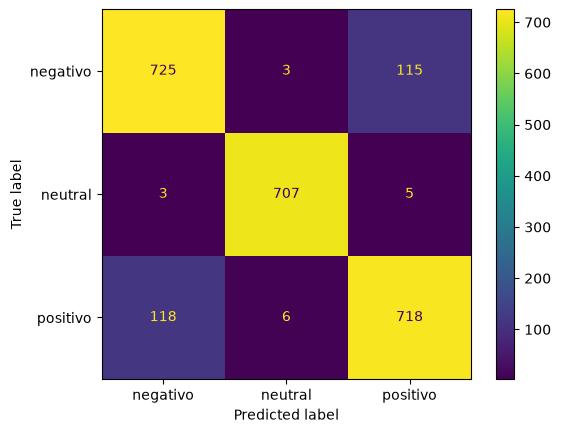

In [43]:
etapa1_final, etapa2_final = entrenar_cascada(
    X_train_transformed, y_train, LinearSVC(C=1.0), LinearSVC(C=1.0)
)
y_pred_cascade = predecir_cascada(X_test_transformed, etapa1_final, etapa2_final)

print(f"Accuracy Cascada: {accuracy_score(y_test, y_pred_cascade):.4f}")
print(f"Accuracy LinearSVC plano: {accuracy_linear_svc:.4f}")
print(classification_report(y_test, y_pred_cascade))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cascade)
plt.show()

,media,desviación,varianza,IC 95% inf,IC 95% sup
accuracy,0.895968,0.006242,0.000039,0.884583,0.907927
f1_macro,0.900537,0.005855,0.000034,0.889539,0.911838
f1_negativo,0.858661,0.009115,0.000083,0.841362,0.876457
f1_neutral,0.988245,0.002799,0.000008,0.982501,0.993245
f1_positivo,0.854705,0.009346,0.000087,0.836831,0.872415


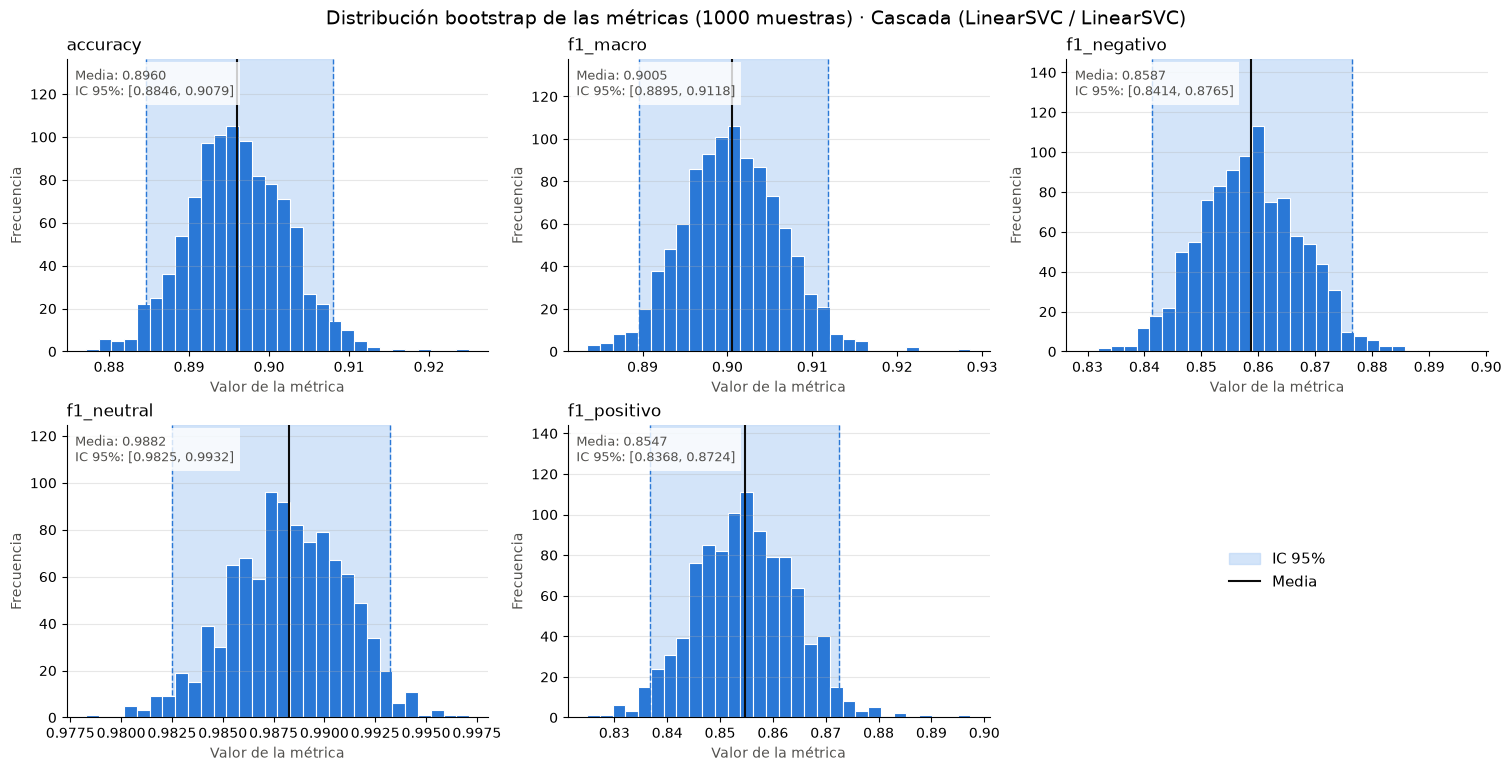

In [45]:
bootstrap_results_cascade, bootstrap_summary_cascade = bootstrap_evaluation(
    y_test, y_pred_cascade, classes=np.unique(y_train), model_name="Cascada (LinearSVC / LinearSVC)"
)

## Creación de la submission

In [36]:
def create_submission_file(eval_file, model, filename="submission_3.csv"):
    eval_file = pd.read_csv(eval_file)
    eval_file_transformed = preprocessor.transform(eval_file)
    submission = pd.DataFrame({
        "id": eval_file["id"],
        "answer": model.predict(eval_file_transformed)
    })
    submission.to_csv(filename, index=False)
    
create_submission_file("data/eval.csv", linear_svc)

In [47]:
def create_submission_cascada(eval_file, etapa1, etapa2, filename="submission_cascada.csv"):
    eval_df = pd.read_csv(eval_file)
    pd.DataFrame({
        "id": eval_df["id"],
        "answer": predecir_cascada(preprocessor.transform(eval_df), etapa1, etapa2),
    }).to_csv(filename, index=False)

create_submission_cascada("data/eval.csv", etapa1_final, etapa2_final)